# 📊 Churn Prediction & Customer Segmentation
## Exploration des techniques et modèles utilisés dans le projet

---
**Dataset** : [E-Commerce Data - Kaggle](https://www.kaggle.com/datasets/carrie1/ecommerce-data)  
**Objectif** : Prédire le churn client + Segmenter les clients par comportement RFM  
**Modèles** : Random Forest (classification) + KMeans (clustering)


## 1. 📦 Imports & Configuration

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("✅ Imports OK")


✅ Imports OK


## 2. 📂 Chargement des données

In [ ]:
df = pd.read_csv("data/raw/data.csv", encoding="latin-1")
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()


Shape : (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [46]:
# Infos générales
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [48]:
# Valeurs manquantes
missing = df.isnull().sum()
missing[missing > 0]


Description      1454
CustomerID     135080
dtype: int64

## 3. 🧹 Nettoyage des données

**Étapes appliquées :**
- Suppression des lignes sans `CustomerID`
- Filtrage des quantités et prix négatifs (retours/erreurs)
- Conversion des types de données


In [51]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Après nettoyage : {df.shape}")
df.describe()


Après nettoyage : (397884, 9)


,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


## 4. 🔍 Analyse Exploratoire (EDA)

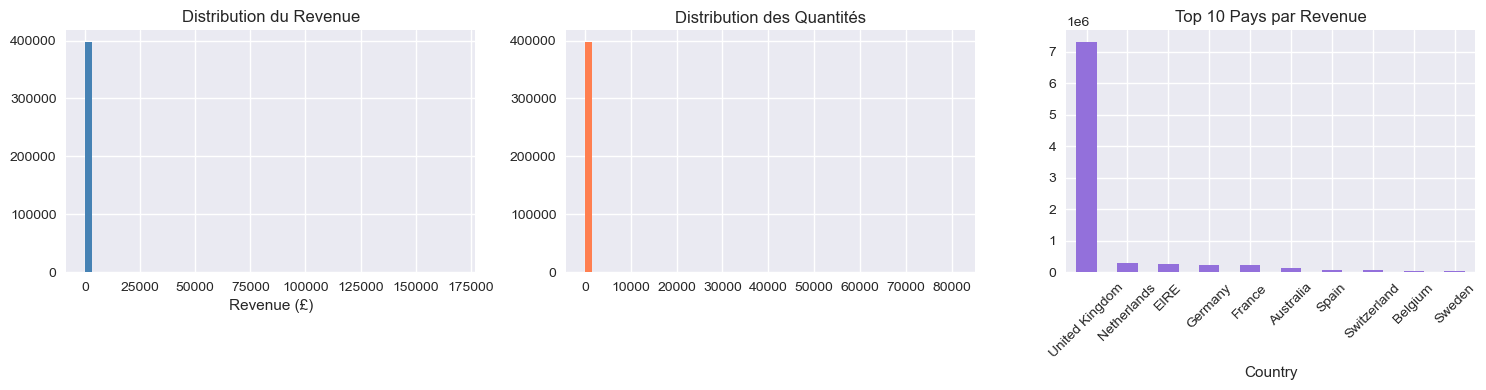

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["Revenue"].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution du Revenue")
axes[0].set_xlabel("Revenue (£)")

df["Quantity"].hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title("Distribution des Quantités")

df.groupby("Country")["Revenue"].sum().nlargest(10).plot(kind="bar", ax=axes[2], color='mediumpurple')
axes[2].set_title("Top 10 Pays par Revenue")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


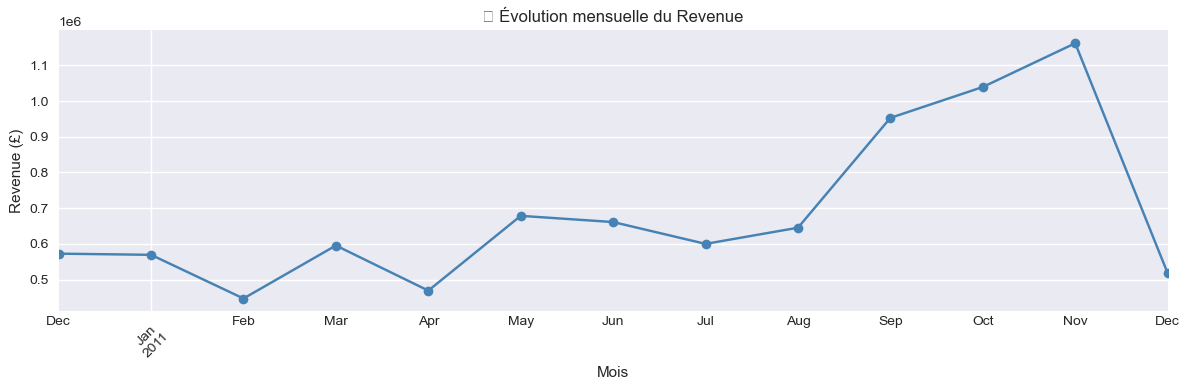

In [54]:
# Ventes par mois
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12, 4))
monthly.plot(kind="line", marker='o', color='steelblue')
plt.title("📈 Évolution mensuelle du Revenue")
plt.xlabel("Mois")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. 📐 Feature Engineering — RFM

**RFM = Recency, Frequency, Monetary**

| Feature | Définition |
|---------|-----------|
| **Recency** | Nombre de jours depuis le dernier achat |
| **Frequency** | Nombre de commandes distinctes |
| **Monetary** | Montant total dépensé (£) |

> Plus la Recency est **faible** → client actif  
> Plus la Frequency et Monetary sont **élevées** → client VIP


In [57]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

print(f"Clients uniques : {len(rfm)}")
rfm.describe()


Clients uniques : 4338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


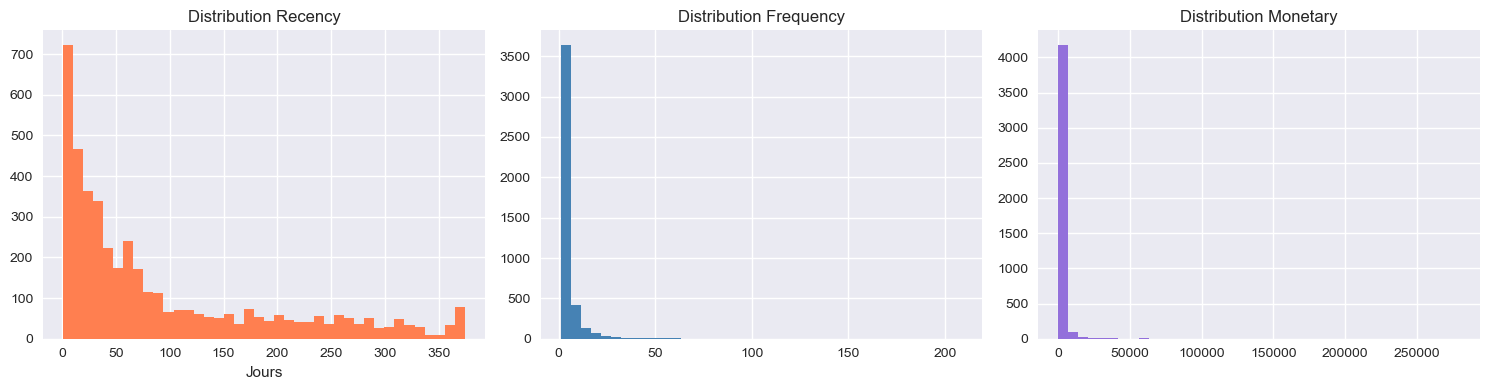

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm["Recency"].hist(bins=40, ax=axes[0], color='coral')
axes[0].set_title("Distribution Recency")
axes[0].set_xlabel("Jours")

rfm["Frequency"].hist(bins=40, ax=axes[1], color='steelblue')
axes[1].set_title("Distribution Frequency")

rfm["Monetary"].hist(bins=40, ax=axes[2], color='mediumpurple')
axes[2].set_title("Distribution Monetary")

plt.tight_layout()
plt.show()


## 6. 🏷️ Création du label Churn

**Règle métier** :  
- `Churn = 1` → client inactif depuis plus de la **médiane de Recency**  
- `Churn = 0` → client actif (achat récent)

> Utiliser la médiane assure un équilibre **50/50** entre les deux classes.


Seuil Recency (médiane) : 51 jours

Distribution du Churn :
Churn
0    2188
1    2150
Name: count, dtype: int64



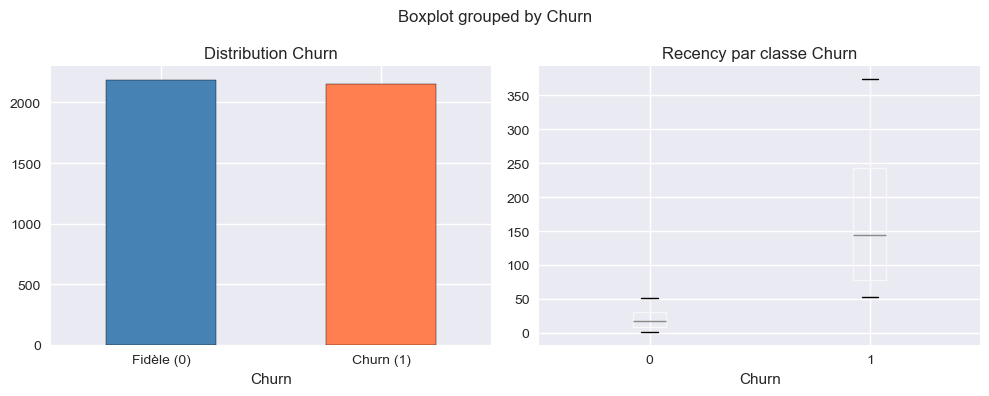

In [60]:
median_recency = rfm["Recency"].median()
rfm["Churn"] = (rfm["Recency"] > median_recency).astype(int)

print(f"Seuil Recency (médiane) : {median_recency:.0f} jours")
print()
print("Distribution du Churn :")
print(rfm["Churn"].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

rfm["Churn"].value_counts().plot(kind="bar", ax=axes[0],
    color=["steelblue", "coral"], edgecolor="black")
axes[0].set_title("Distribution Churn")
axes[0].set_xticklabels(["Fidèle (0)", "Churn (1)"], rotation=0)

rfm.boxplot(column="Recency", by="Churn", ax=axes[1])
axes[1].set_title("Recency par classe Churn")
axes[1].set_xlabel("Churn")

plt.tight_layout()
plt.show()


## 7. ⚙️ Preprocessing — StandardScaler + PCA

**StandardScaler** : Normalise les features (moyenne=0, écart-type=1)  
**PCA** : Réduit la dimensionnalité tout en conservant le maximum de variance


In [62]:
X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Churn"]

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Avant scaling :")
print(pd.DataFrame(X_scaled, columns=X.columns).describe().round(2))


Avant scaling :
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean      0.00       0.00      0.00
std       1.00       1.00      1.00
min      -0.92      -0.43     -0.23
25%      -0.75      -0.43     -0.19
50%      -0.42      -0.30     -0.15
75%       0.49       0.09     -0.04
max       2.81      26.60     30.95


Variance expliquée par composante : [0.555 0.302]
Variance totale expliquée : 85.8%


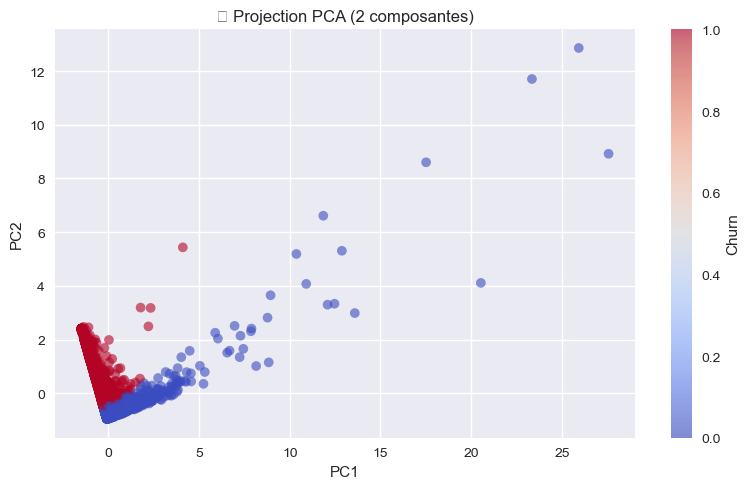

In [63]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par composante : {pca.explained_variance_ratio_.round(3)}")
print(f"Variance totale expliquée : {pca.explained_variance_ratio_.sum():.1%}")

# Visualisation PCA
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y, cmap='coolwarm', alpha=0.6, edgecolors='none')
plt.colorbar(scatter, label='Churn')
plt.title("📊 Projection PCA (2 composantes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 8. 🌲 Modèle de Classification — Random Forest

**Random Forest** = ensemble d'arbres de décision entraînés en parallèle  

**Avantages :**
- Robuste au surapprentissage
- Gère bien les données déséquilibrées avec `class_weight='balanced'`
- Fournit des probabilités de prédiction


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("📊 Rapport de classification :")
print(classification_report(y_test, preds, target_names=["Fidèle", "Churn"]))


📊 Rapport de classification :
              precision    recall  f1-score   support

      Fidèle       0.99      1.00      1.00       438
       Churn       1.00      0.99      1.00       430

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



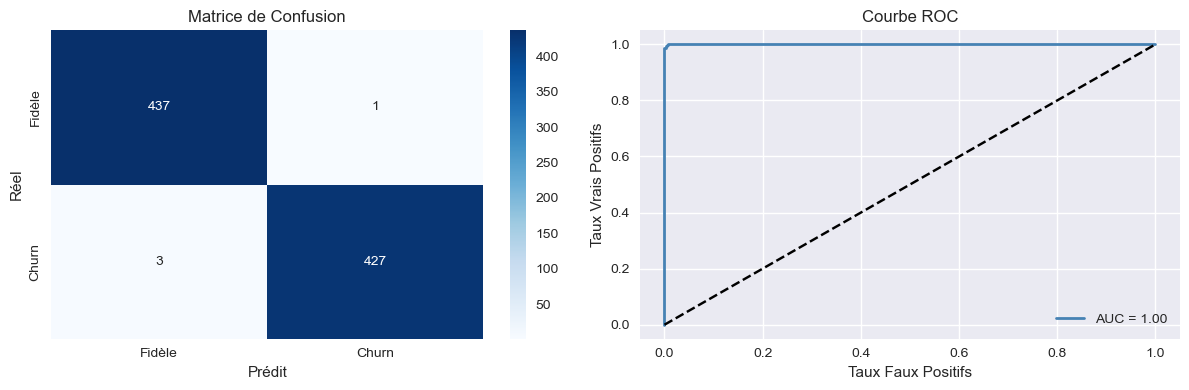

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=["Fidèle", "Churn"],
            yticklabels=["Fidèle", "Churn"])
axes[0].set_title("Matrice de Confusion")
axes[0].set_ylabel("Réel")
axes[0].set_xlabel("Prédit")

# Courbe ROC
proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title("Courbe ROC")
axes[1].set_xlabel("Taux Faux Positifs")
axes[1].set_ylabel("Taux Vrais Positifs")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. 🔵 Segmentation Client — KMeans Clustering

**KMeans** regroupe les clients en **4 segments** basés sur leur comportement RFM :

| Segment | Profil typique |
|---------|---------------|
| 0 | Champions (récent, fréquent, gros panier) |
| 1 | Clients à risque (inactifs) |
| 2 | Nouveaux clients (récent, peu fréquent) |
| 3 | Clients réguliers (moyen sur tout) |


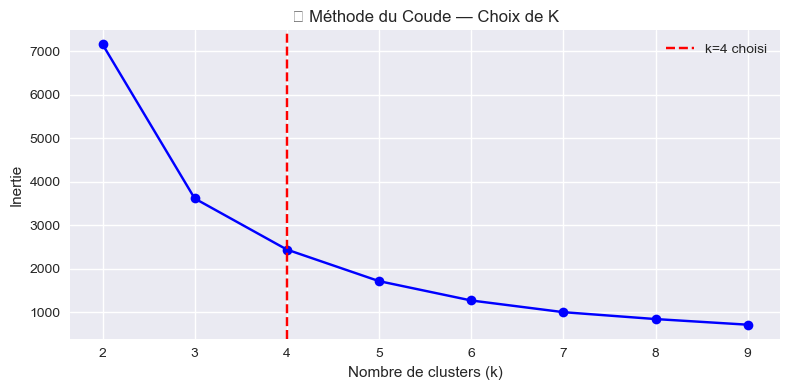

In [69]:
# Méthode du coude pour choisir k
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.axvline(x=4, color='red', linestyle='--', label='k=4 choisi')
plt.title("📐 Méthode du Coude — Choix de K")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.legend()
plt.tight_layout()
plt.show()


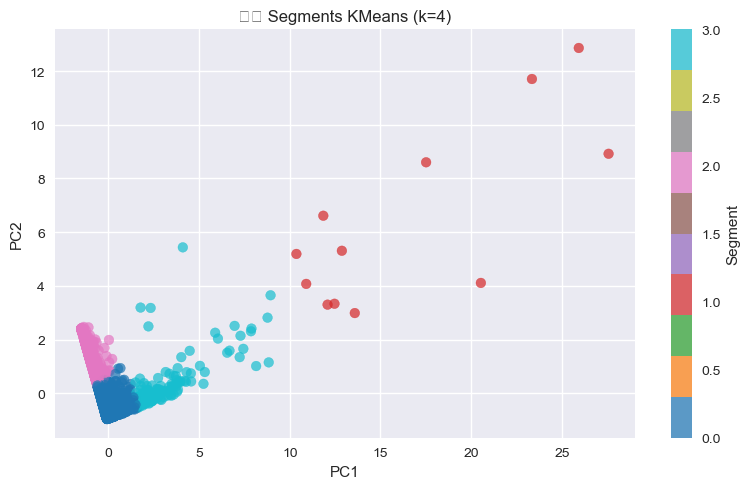

In [71]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Segment"] = kmeans.fit_predict(X_pca)

# Visualisation des segments
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=rfm["Segment"], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Segment')
plt.title("🗂️ Segments KMeans (k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


Profil moyen par segment :
         Recency  Frequency  Monetary
Segment                              
0           43.3        3.8    1391.1
1            7.8       86.8  130361.3
2          247.8        1.5     479.2
3           15.7       23.7   14870.6


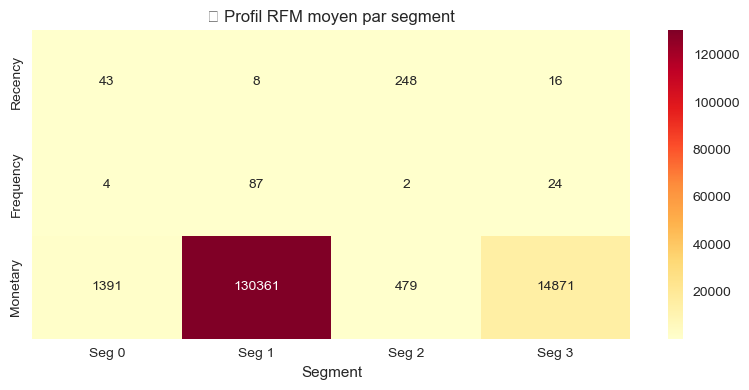

In [72]:
# Profil moyen de chaque segment
profile = rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().round(1)
print("Profil moyen par segment :")
print(profile)

# Heatmap des profils
plt.figure(figsize=(8, 4))
sns.heatmap(profile.T, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=[f"Seg {i}" for i in range(4)])
plt.title("🔥 Profil RFM moyen par segment")
plt.tight_layout()
plt.show()


## 10. 📋 Résumé du Pipeline

```
data/raw/data.csv
       │
       ▼
  preprocessing.py
  ├── Nettoyage (dropna, filtres)
  ├── RFM Feature Engineering
  ├── Label Churn (médiane Recency)
  ├── StandardScaler
  └── PCA (2 composantes)
       │
       ▼
  train_model.py
  ├── RandomForestClassifier (class_weight=balanced)
  └── KMeans (k=4)
       │
       ▼
  models/
  ├── model.pkl    → prédiction churn
  ├── kmeans.pkl   → segmentation
  ├── scaler.pkl   → normalisation
  └── pca.pkl      → réduction
       │
       ▼
  app/app.py (Flask API)
  ├── POST /predict  → churn 0 ou 1
  └── POST /segment  → segment 0,1,2,3
```

### 🎯 Input attendu par l'API
```json
{"data": [Recency, Frequency, Monetary]}
```
Exemple fidèle : `[5, 12, 1500]`  
Exemple churn  : `[300, 1, 15]`
